# 06 — Sentiment Scoring with FinBERT
Score Reddit posts and news headlines, aggregate to a daily sentiment index.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import os

plt.rcParams['figure.dpi'] = 120
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Load Models

Two models — each optimised for its source:
- **FinBERT** (`ProsusAI/finbert`) for news headlines — trained on financial news (Reuters, Bloomberg)
- **RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) for Reddit — trained on social media text

In [2]:
# FinBERT — for news headlines
FINBERT_NAME = 'ProsusAI/finbert'
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
finbert = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME).to(DEVICE)
finbert.eval()
print('FinBERT loaded. Labels:', finbert.config.id2label)

# RoBERTa — for Reddit posts (social media language)
ROBERTA_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME).to(DEVICE)
roberta.eval()
print('RoBERTa loaded. Labels:', roberta.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT loaded. Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded. Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 2. Scoring function

In [3]:
def score_with_finbert(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with FinBERT. Used for financial news headlines.
    Label order: positive=0, negative=1, neutral=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    # Process in chunks of batch_size — GPU handles all texts in a chunk in parallel
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Tokenize: pad shorter texts to match the longest in this batch,
        # truncate anything over 512 tokens (BERT's hard limit)
        enc = finbert_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)

        with torch.no_grad():  # no gradients needed — inference only, saves memory
            # Run the batch through the model, then convert raw logits → probabilities
            # softmax over dim=-1 (the 3 class scores) so each row sums to 1
            # .cpu() moves the result off the GPU back to RAM; .numpy() for indexing
            probs = softmax(finbert(**enc).logits, dim=-1).cpu().numpy()

        # probs shape: (batch_size, 3) — each row is one text, each column one class
        all_pos.extend(probs[:, 0])  # FinBERT label 0 = positive
        all_neg.extend(probs[:, 1])  # FinBERT label 1 = negative
        all_neu.extend(probs[:, 2])  # FinBERT label 2 = neutral

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        # score in [-1, 1]: +1 = fully positive, -1 = fully negative, 0 = neutral
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


def score_with_roberta(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with Twitter-RoBERTa. Used for Reddit posts.
    Label order: negative=0, neutral=1, positive=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = roberta_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            probs = softmax(roberta(**enc).logits, dim=-1).cpu().numpy()

        # RoBERTa label order differs from FinBERT — must map columns correctly
        # or sentiment scores will be flipped for Reddit posts
        all_neg.extend(probs[:, 0])  # RoBERTa label 0 = negative
        all_neu.extend(probs[:, 1])  # RoBERTa label 1 = neutral
        all_pos.extend(probs[:, 2])  # RoBERTa label 2 = positive

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


# ── Model comparison on same test texts ──────────────────────────────────────
test_texts = [
    'Silver is going to the moon! Buy buy buy!',       # retail bullish slang
    'Silver prices crash amid rising dollar and Fed hawkishness.',  # formal bearish
    'Silver traded flat today with low volume.',        # neutral
]

print('=== FinBERT (trained on financial news) ===')
print(score_with_finbert(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())

print('\n=== RoBERTa (trained on social media) ===')
print(score_with_roberta(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())


=== FinBERT (trained on financial news) ===
   positive  negative  neutral  sentiment_score
0     0.050     0.034    0.916            0.016
1     0.048     0.870    0.082           -0.822
2     0.061     0.882    0.058           -0.821

=== RoBERTa (trained on social media) ===
   positive  negative  neutral  sentiment_score
0     0.967     0.004    0.029            0.964
1     0.018     0.572    0.410           -0.554
2     0.046     0.146    0.808           -0.100


In [4]:
def score_finbert_long(texts, batch_size=32, max_len=512, max_chunks=6):
    """FinBERT sentiment for *long* documents (article bodies), getting around BERT's 512-token cap.

    Each text is split into <=510-token chunks (room for [CLS]/[SEP]); FinBERT scores every chunk;
    the per-document score is the token-length-weighted mean of (P_positive - P_negative).
    `max_chunks` caps very long pieces (e.g. earnings-call transcripts) at the first ~3,000 tokens
    — financial articles front-load their thesis, so the tail adds little but compute. Returns a 1-D
    numpy array: one signed score in [-1, 1] per input text (parallel to score_with_finbert's
    'sentiment_score').
    """
    cls, sep, pad = (finbert_tokenizer.cls_token_id, finbert_tokenizer.sep_token_id,
                     finbert_tokenizer.pad_token_id)
    body = max_len - 2  # tokens left for content after [CLS] and [SEP]

    # 1. Tokenize each doc once (no special tokens) and split into <=body-sized chunks, tracking
    #    which doc each chunk came from and its real length (for the length-weighted mean).
    chunk_ids, chunk_doc, chunk_len = [], [], []
    for di, t in enumerate(texts):
        ids = finbert_tokenizer(str(t), add_special_tokens=False, truncation=False)['input_ids']
        if not ids:                                   # empty / NaN body -> one neutral pad token
            ids = [pad]
        for n, start in enumerate(range(0, len(ids), body)):
            if n >= max_chunks:
                break
            piece = ids[start:start + body]
            chunk_ids.append([cls] + piece + [sep])
            chunk_doc.append(di)
            chunk_len.append(len(piece))

    # 2. Score all chunks in padded batches (pos - neg, like score_with_finbert).
    signed = []
    for i in range(0, len(chunk_ids), batch_size):
        batch = chunk_ids[i:i + batch_size]
        width = max(len(x) for x in batch)
        ids_t = torch.full((len(batch), width), pad, dtype=torch.long)
        att_t = torch.zeros((len(batch), width), dtype=torch.long)
        for j, x in enumerate(batch):
            ids_t[j, :len(x)] = torch.tensor(x); att_t[j, :len(x)] = 1
        with torch.no_grad():
            probs = softmax(finbert(input_ids=ids_t.to(DEVICE),
                                    attention_mask=att_t.to(DEVICE)).logits, dim=-1).cpu().numpy()
        signed.extend(probs[:, 0] - probs[:, 1])      # FinBERT: 0=positive, 1=negative

    # 3. Length-weighted mean of the chunk scores, per document.
    agg = pd.DataFrame({'doc': chunk_doc,
                        'num': np.array(signed) * np.array(chunk_len),
                        'den': chunk_len})
    g = agg.groupby('doc')[['num', 'den']].sum()
    return (g['num'] / g['den']).reindex(range(len(texts))).fillna(0.0).to_numpy()


## 3. Score Reddit posts

In [5]:
import pandas as pd                                                                                                  
df = pd.read_csv('../../data/raw/reddit_history.csv', parse_dates=['created_utc'])                                         
print(df.shape)                         
print(df['subreddit'].value_counts())                                                                                
print(df['created_utc'].min(), "→", df['created_utc'].max())                                                         
print(df['created_utc'].dt.year.value_counts().sort_index())

(657291, 8)
subreddit
Wallstreetsilver    433579
Silverbugs          223712
Name: count, dtype: int64
2015-03-28 02:59:50 → 2026-05-03 21:54:16
created_utc
2015      8595
2016     13285
2017     13184
2018     11322
2019     14075
2020     22672
2021    213745
2022    180650
2023     73578
2024     34827
2025     46872
2026     24486
Name: count, dtype: int64


In [6]:
df.head()

,id,subreddit,created_utc,title,selftext,score,num_comments,upvote_ratio
0,mdas9v,Wallstreetsilver,2021-03-25 22:58:49,2021 Silver Valiant from Royal Mint - Gorgeous...,NaN,37,7,0.96
1,mdarz7,Wallstreetsilver,2021-03-25 22:58:23,4 kilos silver shot. $28.15/oz and good for ba...,NaN,37,6,0.93
2,mdaqef,Wallstreetsilver,2021-03-25 22:56:06,T minus ? days and counting before launch,I spend a lot of time with WSS. \n\nIt feels ...,99,34,1.00
3,mdapph,Wallstreetsilver,2021-03-25 22:55:03,Sold Royal Caribbean shares for silver!,NaN,53,5,0.97
4,mdap83,Wallstreetsilver,2021-03-25 22:54:24,A Shout Out To Bison Bullion,I just placed an order and you can support fel...,16,6,0.84


       reddit_posts  news_articles
count   4055.000000    4055.000000
mean     162.093958      15.430826
std      229.259267      16.776384
min       10.000000       0.000000
25%       36.000000       0.000000
50%       67.000000      12.000000
75%      148.000000      25.000000
max     2254.000000     150.000000


<Axes: title={'center': 'Daily post/article counts'}>

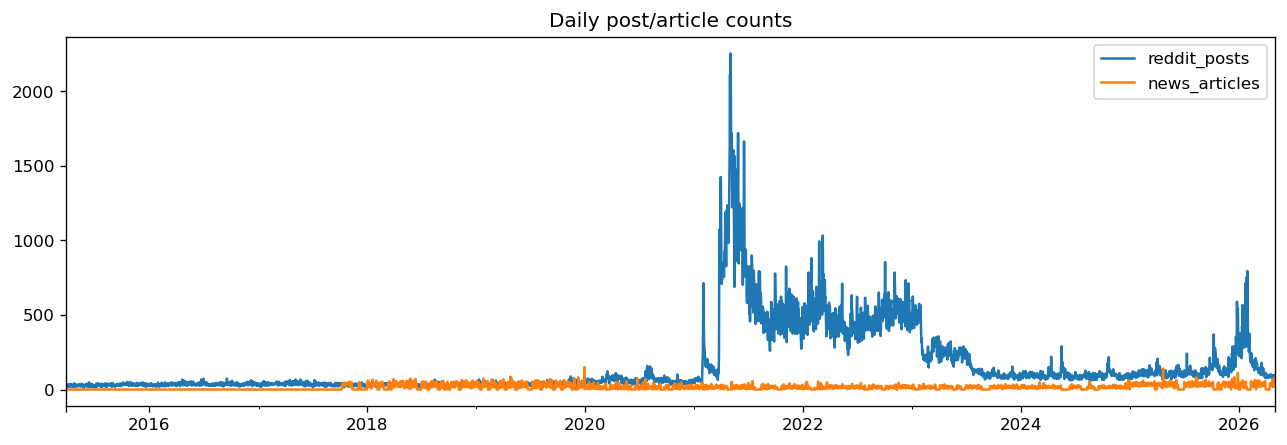

In [7]:
import pandas as pd
                                                                                                  
reddit = pd.read_csv('../../data/raw/reddit_history.csv', parse_dates=['created_utc'])
news   = pd.read_csv('../../data/raw/news_gdelt.csv')                                                
news['date'] = pd.to_datetime(news['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
                                                                                                  
reddit_daily = reddit.set_index('created_utc').resample('D').size().rename('reddit_posts')
news_daily   = news.set_index('date').resample('D').size().rename('news_articles')                
                                                                                                  
counts = pd.concat([reddit_daily, news_daily], axis=1).fillna(0).astype(int)                      
print(counts.describe())                                                                          
counts.plot(figsize=(13, 4), title='Daily post/article counts')       

In [8]:
reddit_path = '../../data/raw/reddit_history.csv'

if os.path.exists(reddit_path):
    reddit = pd.read_csv(reddit_path, parse_dates=['created_utc'])
    reddit = reddit.dropna(subset=['title'])

    # Combine title + first 100 chars of body for more signal
    reddit['text'] = reddit['title'] + '. ' + reddit['selftext'].fillna('').str[:100]

    # Use RoBERTa — better suited for Reddit's informal language than FinBERT
    print(f'Scoring {len(reddit):,} Reddit posts with RoBERTa...')
    scores = score_with_roberta(reddit['text'].tolist())

    # Attach sentiment columns to the original DataFrame (reset index so concat aligns)
    reddit = pd.concat([reddit.reset_index(drop=True), scores], axis=1)
    reddit['date'] = pd.to_datetime(reddit['created_utc']).dt.date

    # Weight by upvotes — a post with 5000 upvotes carries more community signal
    # than one with 1; clip at 1 so downvoted/zero-score posts still contribute minimally
    reddit['weight'] = reddit['score'].clip(lower=1)
    reddit['weighted_sentiment'] = reddit['sentiment_score'] * reddit['weight']

    daily_reddit = (
        reddit.groupby('date')
        .agg(
            reddit_sentiment=('weighted_sentiment', 'sum'),  # sum of weight * sentiment
            reddit_weight_sum=('weight', 'sum'),             # sum of weights (denominator)
            reddit_post_count=('sentiment_score', 'count'),  # number of posts that day
        )
        # Divide to get weighted average — keeps the score in [-1, 1] regardless of post volume
        .assign(reddit_sentiment=lambda d: d['reddit_sentiment'] / d['reddit_weight_sum'])
    )
    daily_reddit.index = pd.to_datetime(daily_reddit.index)
    print(daily_reddit.tail())
else:
    print('No Reddit history file — run collect_reddit.py first.')
    daily_reddit = pd.DataFrame()


Scoring 657,291 Reddit posts with RoBERTa...


KeyboardInterrupt: 

## 4. Score GDELT news

### Methodological note — English-only filter on GDELT

GDELT is a **multilingual news aggregator** — its silver-related coverage spans
dozens of languages (Spanish, Mandarin, Russian, Arabic, etc.). In our fetch,
roughly 85% of articles are non-English. **FinBERT is trained exclusively on
English financial text** (Reuters, Bloomberg, financial filings); running it on
non-English headlines produces uninterpretable scores, since the model has no
representation of those languages.

The `language == 'English'` filter applied below is therefore a **hard model
requirement**, not a methodological choice. The asymmetry with the Reddit
pipeline (no filter there) is justified by the different language characteristics
of the two sources:

| Source  | Language characteristic              | Filter applied?               | Reason                              |
|---------|--------------------------------------|-------------------------------|-------------------------------------|
| Reddit  | Implicitly English (subreddit-gated) | No                            | Source pre-filtered by community    |
| GDELT   | Multilingual (English ≈ 15%)         | Yes (`language == 'English'`) | Required by FinBERT's training data |

A multilingual model (e.g. XLM-R fine-tuned for finance) would let us score the
non-English ~85% as well, but at the cost of mixing model regimes — we accept
the smaller English-only sample for cross-document comparability.

In [ ]:
news_path = '../../data/raw/news_gdelt.csv'

if os.path.exists(news_path):
    news = pd.read_csv(news_path, parse_dates=['seendate'])  # GDELT uses 'seendate' not 'datetime'
    news = news.dropna(subset=['title'])  # can't score a headline that doesn't exist

    # FinBERT is English-only — filter out non-English articles before scoring
    # to avoid meaningless scores on foreign-language text
    if 'language' in news.columns:
        before = len(news)
        news = news[news['language'] == 'English']
        print(f'Language filter: {before:,} → {len(news):,} articles ({before - len(news):,} dropped)')

    print(f'Scoring {len(news):,} news headlines...')
    news_scores = score_with_finbert(news['title'].tolist())  # titles only — GDELT has no body text

    # reset_index on both sides so rows align correctly before concatenating
    news = pd.concat([news.reset_index(drop=True), news_scores], axis=1)

    # seendate is a full timestamp — strip to date only so we can group by day
    news['date'] = pd.to_datetime(news['seendate']).dt.date

    daily_news = (
        news.groupby('date')['sentiment_score']
        .agg(['mean', 'count'])  # mean sentiment + article count for that day
        .rename(columns={'mean': 'news_sentiment', 'count': 'news_article_count'})
        # no upvote weighting here — all news articles treated equally
    )
    # groupby returns plain date strings; convert to datetime to align with other DataFrames
    daily_news.index = pd.to_datetime(daily_news.index)
    print(daily_news.tail())
else:
    print('No GDELT news file — run collect_news.py first.')
    daily_news = pd.DataFrame()


## 4b. Score paid news (NewsAPI.ai bodies)

A **second, independent** news signal alongside GDELT — not a replacement. `news_newsapi.csv`
(`collect_news_newsapi.py`) is **20.6k English articles from a reputable-source whitelist** (Kitco,
FXStreet, Reuters, WSJ, Bloomberg, …), 2015→present, **with full bodies** and ≥1 article every week —
fixing GDELT's title-only / multilingual / post-2017 / gappy limits. Three daily `news_paid_*` columns:

- **`news_paid_sentiment_body`** — FinBERT on the **full body** via `score_finbert_long` (chunk into
  ≤512-tok windows → length-weighted mean of P(pos)−P(neg)). Primary paid series.
- **`news_paid_sentiment_title`** — FinBERT on the title only (cross-check; FinBERT is sentence-trained,
  so the headline can be cleaner than a diluted body mean).
- **`news_paid_sentiment_vader`** — Event Registry's own per-article sentiment (free, 96% populated).

Keeping both sources lets `technical_features_weekly` / the ablations compare them — a robustness line: *does the
better-sourced signal change the news→return conclusion?* A `keyword=silver` search also catches
non-metal *silver* ("silver lining" idiom, Silver Lake PE, Adam Silver/NBA, medal/screen — ~8% of
titles), dropped below before scoring.

In [9]:
paid_path = '../../data/raw/news_newsapi.csv'

if os.path.exists(paid_path):
    paid = pd.read_csv(paid_path, parse_dates=['dateTime'])
    paid = paid.dropna(subset=['body'])                 # need a body to score

    # Drop non-metal "silver" false positives the keyword search catches — idioms + entities.
    # The worst is "silver lining" (an upbeat idiom that would bias sentiment positive).
    # Filtered here, not in raw/: data/raw is never modified, and the rule stays easy to tweak.
    NON_METAL = (r'silver lining|silver lake|silver screen|silver medal|adam silver'
                 r'|long john silver|silver alert|silver fox|silver surfer|hi-?yo silver')
    drop = paid['title'].fillna('').str.lower().str.contains(NON_METAL, regex=True)
    print(f'Dropping {drop.sum():,} non-metal "silver" titles (lining / Silver Lake / NBA / sport ...)')
    paid = paid[~drop].reset_index(drop=True)

    # Title leads the body so the headline tone lands in the first chunk.
    texts = (paid['title'].fillna('') + '. ' + paid['body']).tolist()

    print(f'Scoring {len(paid):,} article bodies with FinBERT (chunked)...')
    paid['news_paid_sentiment_body'] = score_finbert_long(texts)                         # full-body (primary)
    paid['news_paid_sentiment_title'] = score_with_finbert(
        paid['title'].fillna('').tolist())['sentiment_score'].to_numpy()            # title-only cross-check
    # 'sentiment' column is Event Registry's own per-article score — kept as a second cross-check

    paid['date'] = paid['dateTime'].dt.date
    daily_news_paid = paid.groupby('date').agg(
        news_paid_sentiment_body=('news_paid_sentiment_body', 'mean'),                # FinBERT body (primary)
        news_paid_sentiment_title=('news_paid_sentiment_title', 'mean'),    # FinBERT title
        news_paid_sentiment_vader=('sentiment', 'mean'),                       # Event Registry built-in
        news_paid_article_count=('news_paid_sentiment_body', 'count'),
    )
    daily_news_paid.index = pd.to_datetime(daily_news_paid.index)
    print(daily_news_paid.tail())
else:
    print('No NewsAPI.ai news file — run collect_news_newsapi.py first.')
    daily_news_paid = pd.DataFrame()


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (707 > 512). Running this sequence through the model will result in indexing errors


Dropping 1,538 non-metal "silver" titles (lining / Silver Lake / NBA / sport ...)
Scoring 19,118 article bodies with FinBERT (chunked)...
            news_paid_sentiment  news_paid_sentiment_title  \
date                                                         
2026-06-15            -0.001567                   0.210508   
2026-06-16            -0.108476                   0.014793   
2026-06-17            -0.052671                   0.230588   
2026-06-18            -0.219011                   0.013532   
2026-06-19            -0.579892                  -0.431989   

            news_paid_sentiment_er  news_paid_article_count  
date                                                         
2026-06-15                0.174902                       20  
2026-06-16                0.149733                       22  
2026-06-17                0.212918                       17  
2026-06-18                0.165577                       18  
2026-06-19                0.116667                     

## 4c. Quick-add — fold paid columns into the existing CSV (skip Reddit re-scoring)

To add the `news_paid_*` columns to `daily_sentiment.csv` **without** the slow Reddit RoBERTa pass:
run §1 (imports) → load-models → §2 (both scorer cells) → §4b → **this cell**. Idempotent (drops any
prior `news_paid_*` first); mirrors §6c's GKG fold. A full top-to-bottom run does the same via §5,
so this cell is the fast standalone path.

In [10]:
# Quick-add path: fold the paid-news columns into the EXISTING daily_sentiment.csv without
# re-running §3 (Reddit) or the full §5 rebuild. Idempotent — drops any prior news_paid_* first.
out_path = '../../data/processed/daily_sentiment.csv'
base = pd.read_csv(out_path, index_col=0, parse_dates=True)

paid_cols = ['news_paid_sentiment_body', 'news_paid_sentiment_title',
             'news_paid_sentiment_vader', 'news_paid_article_count']
base = base.drop(columns=[c for c in paid_cols if c in base.columns])

# Same treatment §5 gives every source: union the dates, then business-day forward-fill.
merged = pd.concat([base, daily_news_paid], axis=1).sort_index().resample('B').ffill()
merged.to_csv(out_path)
print('Folded paid news ->', out_path, '| shape', merged.shape)
print('columns:', list(merged.columns))
merged[paid_cols].dropna().tail()


Folded paid news -> ../data/processed/daily_sentiment.csv | shape (2990, 13)
columns: ['reddit_sentiment', 'reddit_weight_sum', 'reddit_post_count', 'news_sentiment', 'news_article_count', 'sentiment_score', 'gkg_sentiment', 'gkg_article_count', 'sentiment_score_gkg', 'news_paid_sentiment', 'news_paid_sentiment_title', 'news_paid_sentiment_er', 'news_paid_article_count']


,news_paid_sentiment,news_paid_sentiment_title,news_paid_sentiment_er,news_paid_article_count
date,,,,
2026-06-15,-0.001567,0.210508,0.174902,20.0
2026-06-16,-0.108476,0.014793,0.149733,22.0
2026-06-17,-0.052671,0.230588,0.212918,17.0
2026-06-18,-0.219011,0.013532,0.165577,18.0
2026-06-19,-0.579892,-0.431989,0.116667,8.0


## 5. Combine into daily sentiment index

In [ ]:
sentiment_frames = [f for f in [daily_reddit, daily_news, daily_news_paid] if not f.empty]

if sentiment_frames:
    daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()

    # Reddit + GDELT-news composite. GKG is a SEPARATE news proxy added by §6c (which reads
    # this CSV and folds in gkg_sentiment + sentiment_score_gkg), so the slow Reddit RoBERTa
    # pass runs here once and persists — the GKG layer can then be re-run on its own.
    gdelt_cols = [c for c in ['reddit_sentiment', 'news_sentiment'] if c in daily_sentiment.columns]
    daily_sentiment['sentiment_score'] = daily_sentiment[gdelt_cols].mean(axis=1)  # Reddit + GDELT

    # Forward-fill weekends/gaps (no posts on weekends)
    # Asier: make sure this is sensible — if we have a gap of several days, should we really carry forward the last sentiment score?
    daily_sentiment = daily_sentiment.resample('B').ffill()  # business days

    os.makedirs('../../data/processed', exist_ok=True)
    daily_sentiment.to_csv('../../data/processed/daily_sentiment.csv')
    print('Saved:', daily_sentiment.shape)
    daily_sentiment.head()
else:
    print('No sentiment data to combine yet.')

## 6a. Score GKG news (FinBERT on the URL slug)

First step of the GKG layer (§6), run after the base CSV in §5. GKG gives full-window
(2015+) silver news but **no titles** and a noisier match, so we make it a *third*
sentiment source on equal footing with Reddit / GDELT-News:

- keep **English** articles (FinBERT is English-only) from a curated precious-metals /
  mining **domain allowlist**;
- derive a headline from the **URL slug** and score it with **FinBERT** — GKG's `tone`
  field tracks whole-body affect, not the headline, so we score a slug-headline rather
  than reuse `tone` (justified empirically in §6b);
- aggregate to a daily `gkg_sentiment`, parallel to `daily_reddit` / `daily_news`.

The scores feed the EDA / justification in **§6b**; `daily_gkg` is then folded into
`daily_sentiment.csv` by **§6c**. Keeping the whole GKG layer after §5 means refreshing
it never re-triggers the slow Reddit pass.

In [ ]:
# ── GKG news: load -> English -> domain allowlist -> FinBERT on URL slug ──────
import re
from urllib.parse import urlparse

gkg = pd.read_csv('../../data/raw/news_gkg.csv')
gkg['date'] = pd.to_datetime(gkg['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
print(f'raw: {len(gkg):,} rows | langs {gkg.language.value_counts().to_dict()}')
gkg = gkg[gkg['language'] == 'English'].copy()          # FinBERT is English-only

# Curated precious-metals / commodity-news domains (audit & extend freely).
# RELEVANT_DOMAINS = {
#     'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
#     'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
#     'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
#     'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
#     'smaulgld.com', 'livecharts.co.uk', 'investing.com',
# }
RELEVANT_DOMAINS = {
    # original curated set
    'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
    'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
    'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
    'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
    'smaulgld.com', 'livecharts.co.uk', 'investing.com',
    # + mining / metals / commodity outlets (sample-verified on-topic)
    'proactiveinvestors.com', 'proactiveinvestors.com.au', 'proactiveinvestors.co.uk',
    'mining.com', 'mining-journal.com', 'miningweekly.com', 'miningnews.net',
    'canadianminingjournal.com', 'northernminer.com', 'miningmx.com', 'nxtmine.com',
    'yourminingnews.com', 'republicofmining.com', 'mining-technology.com',
    'metal.com', 'oilngold.com', 'commodityonline.com', 'resourceinvestor.com',
    'streetwisereports.com', 'streetwisereport.com', 'silverinvestingnews.com',
    'yourmetalnews.com', 'bulliondesk.com',
}
gkg_rel = gkg[gkg['domain'].isin(RELEVANT_DOMAINS)].copy()
print(f'allowlist: {len(gkg_rel):,} relevant English articles '
      f'({len(gkg_rel)/len(gkg)*100:.0f}% of English)')

def slug_name(u):
    # readable headline from a URL slug (GKG has no titles)
    if not isinstance(u, str):
        return ''
    segs = [s for s in urlparse(u).path.split('/') if s]
    if not segs:
        return ''
    seg = max(segs, key=lambda s: sum(c.isalpha() for c in s))   # headline-like segment
    seg = re.sub(r'\.(html?|aspx|php|shtml)$', '', seg, flags=re.I)
    seg = re.sub(r'[-_+]+', ' ', seg)
    seg = re.sub(r'\b\d{4,}\b', '', seg)                       # drop long id numbers
    return seg.strip()[:90]

gkg_names = gkg_rel.assign(name=gkg_rel['url'].map(slug_name))
gkg_names = gkg_names[gkg_names['name'].str.len() > 0].copy()

# FinBERT each UNIQUE slug once (slugs repeat across rows), then map back.
uniq = gkg_names['name'].drop_duplicates().tolist()
print(f'scoring {len(uniq):,} unique slugs with FinBERT ({len(gkg_names):,} articles)... (a few minutes)')
scored = score_with_finbert(uniq)
gkg_names['finbert'] = gkg_names['name'].map(dict(zip(uniq, scored['sentiment_score'])))

# daily GKG sentiment — parallel to daily_reddit / daily_news
daily_gkg = (
    gkg_names.groupby(gkg_names['date'].dt.date)['finbert']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'gkg_sentiment', 'count': 'gkg_article_count'})
)
daily_gkg.index = pd.to_datetime(daily_gkg.index)
# weekly version reused by the §6b deep-dive
gkg_finbert_weekly = (gkg_names.set_index('date')['finbert']
                      .resample('W-FRI').mean().rename('gkg_finbert'))
print(daily_gkg.tail())

raw: 619,654 rows | langs {'English': 518612, 'Other': 101042}
allowlist: 46,152 relevant English articles (9% of English)
scoring 39,627 unique slugs with FinBERT (46,151 articles)... (a few minutes)
            gkg_sentiment  gkg_article_count
date                                        
2026-04-27       0.269857                  5
2026-04-28       0.009253                  2
2026-04-29       0.092056                 11
2026-04-30       0.210429                  9
2026-05-01       0.096406                  6


## 6b. GKG EDA & justification — tone vs FinBERT, and the news→return null

The justification + diagnostics for the GKG layer, sitting between scoring (§6a) and the
CSV fold (§6c): why we score the slug with FinBERT rather than GKG's raw `tone`, how the
GKG and GDELT news signals relate, and whether either forecasts returns. It reuses the
frames built in §6a — nothing is re-scored.

### Coverage and raw-tone EDA

Weekly article volume and the raw `tone` distribution for the filtered GKG set
(`gkg_rel` from §6a).

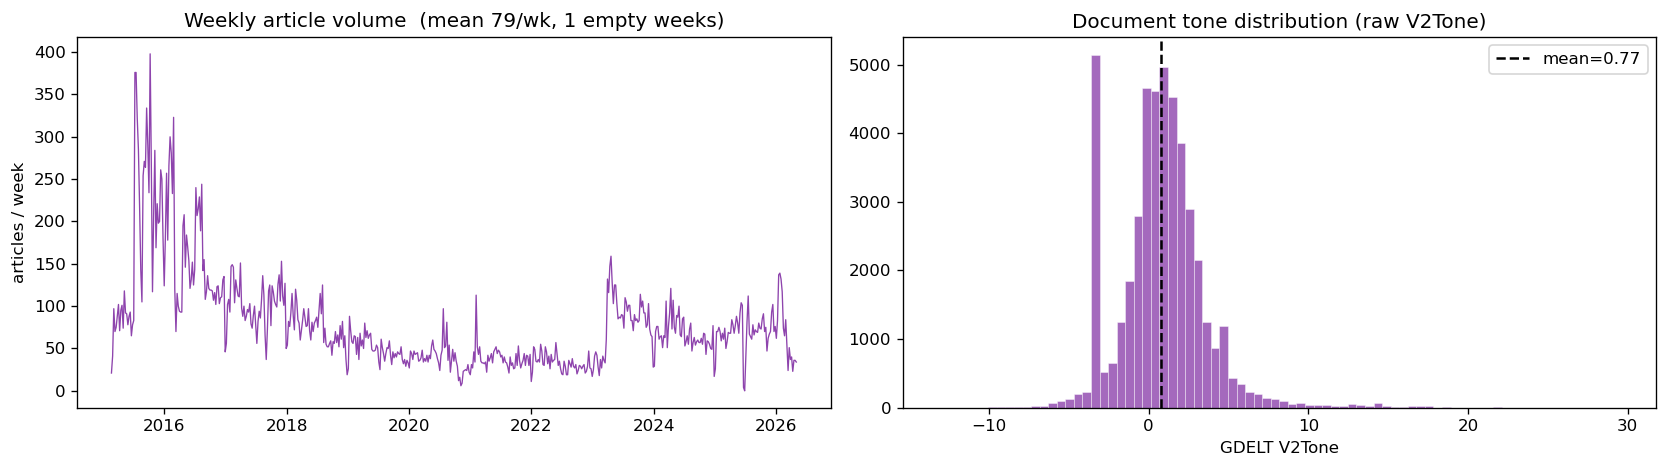

In [ ]:
# ── EDA: weekly article volume + tone distribution (after filter) ───────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

wk_vol = gkg_rel.set_index('date').resample('W-FRI').size()
axes[0].plot(wk_vol.index, wk_vol.values, lw=0.8, color='#8e44ad')
axes[0].set_title(f'Weekly article volume  (mean {wk_vol.mean():.0f}/wk, '
                  f'{int((wk_vol == 0).sum())} empty weeks)')
axes[0].set_ylabel('articles / week')

axes[1].hist(gkg_rel.tone.dropna(), bins=80, color='#8e44ad', alpha=0.8,
             edgecolor='white', linewidth=0.3)
axes[1].axvline(gkg_rel.tone.mean(), color='black', ls='--', lw=1.5,
                label=f'mean={gkg_rel.tone.mean():.2f}')
axes[1].set_title('Document tone distribution (raw V2Tone)')
axes[1].set_xlabel('GDELT V2Tone'); axes[1].legend()
plt.tight_layout(); plt.show()

### Tone → [−1, 1] and weekly aggregation

`tanh(tone / 4)` squashes the raw tone onto FinBERT's `news_sentiment` scale
(std ≈ 0.5). Weekly mean on the W-FRI calendar matches the rest of the pipeline.

In [ ]:
TONE_SCALE = 4.0  # tanh(tone/k): k≈4 gives std≈0.5, matching FinBERT news_sentiment

gkg_rel['gkg_sentiment'] = np.tanh(gkg_rel['tone'] / TONE_SCALE)
gkg_weekly = (
    gkg_rel.set_index('date')['gkg_sentiment']
           .resample('W-FRI').mean()
           .rename('gkg_news_sentiment')
)
print(gkg_weekly.describe().round(3).to_string())
print('\nspan:', gkg_weekly.index.min().date(), '->', gkg_weekly.index.max().date())

count    584.000
mean       0.209
std        0.167
min       -0.498
25%        0.171
50%        0.236
75%        0.299
max        0.586

span: 2015-02-20 -> 2026-05-01


### GKG tone vs FinBERT — do they agree on the 2017+ overlap?

If weekly GKG tone tracks the FinBERT `news_sentiment`, the two are
interchangeable and the 2015–2017 backfill is safe to splice on. If they diverge,
the methodology break matters and the choice must be deliberate. (`daily_news` is
the FinBERT daily series built in §4.)

overlap weeks: 406    correlation: -0.048


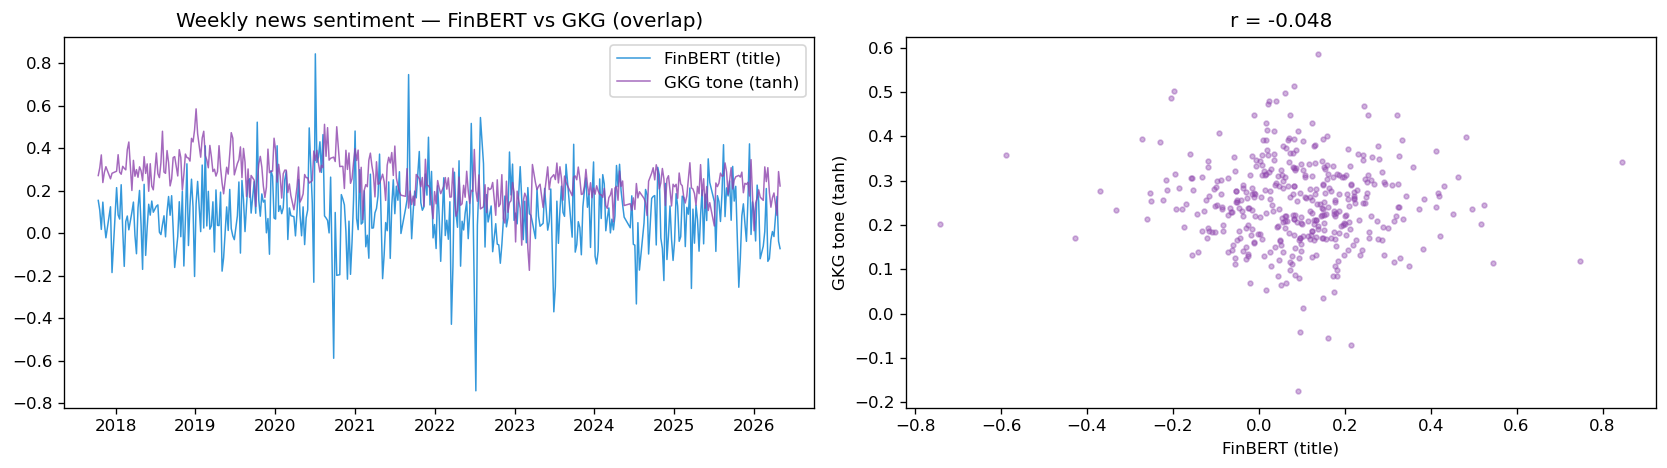

In [ ]:
# FinBERT weekly (from §4 daily_news) vs GKG weekly tone, on their overlap.
finbert_weekly = daily_news['news_sentiment'].resample('W-FRI').mean()

cmp = pd.concat([finbert_weekly.rename('finbert'),
                 gkg_weekly.rename('gkg')], axis=1).dropna()
r = cmp['finbert'].corr(cmp['gkg'])
print(f'overlap weeks: {len(cmp)}    correlation: {r:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cmp.index, cmp['finbert'], lw=0.9, label='FinBERT (title)', color='#3498db')
axes[0].plot(cmp.index, cmp['gkg'], lw=0.9, label='GKG tone (tanh)', color='#8e44ad', alpha=0.8)
axes[0].set_title('Weekly news sentiment — FinBERT vs GKG (overlap)'); axes[0].legend()

axes[1].scatter(cmp['finbert'], cmp['gkg'], s=8, alpha=0.4, color='#8e44ad')
axes[1].set_xlabel('FinBERT (title)'); axes[1].set_ylabel('GKG tone (tanh)')
axes[1].set_title(f'r = {r:+.3f}')
plt.tight_layout(); plt.show()

### Lagged GKG news tone vs silver weekly return

Self-contained — rebuilds both weekly series from raw, then `corr(news_{t-k}, ret_t)`.
`k > 0` is the predictive direction (past news vs current return); a clean null here
is semi-strong-form-EMH evidence, not a failure.

overlap weeks: 584    significance ~ +/-0.083

lag_k
0    0.046
1    0.008
2   -0.037
3   -0.021
4    0.034
5    0.031


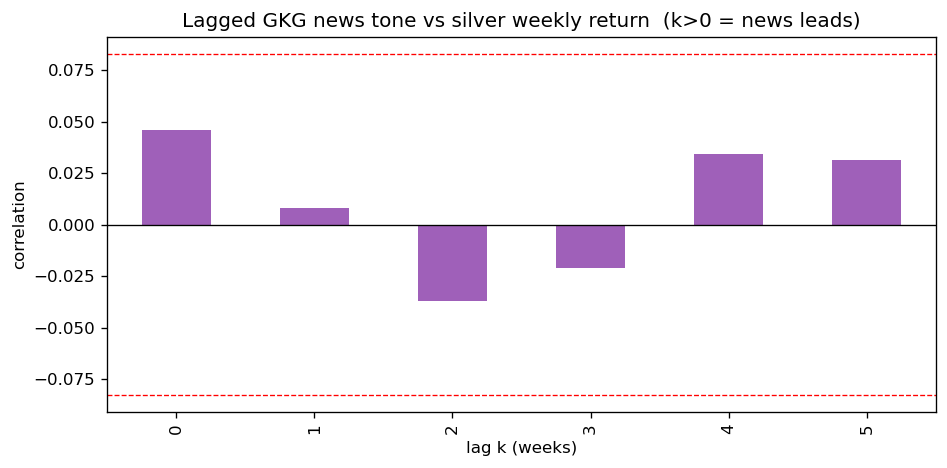

In [ ]:
# Self-contained: silver weekly return + GKG weekly news tone from raw files.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# silver weekly log-return = W-FRI sum of daily log-returns (project convention)
px  = pd.read_csv('../../data/raw/daily_prices.csv', index_col=0, parse_dates=True)['silver']
ret = np.log(px).diff().resample('W-FRI').sum().rename('silver_ret')

# weekly GKG news tone: allowlist -> tanh(tone/4) -> W-FRI mean
# ALLOW = {'kitco.com','goldseiten.de','goldseiten.at','juniorminingnetwork.com',
#          'coinnews.net','mcxcontrol.com','marketscreener.com','4-traders.com',
#          'finanznachrichten.de','aktiencheck.de','bullionvault.com','mineweb.com',
#          'silverseek.com','goldprice.org','sharpspixley.com','goldcore.com',
#          'smaulgld.com','livecharts.co.uk','investing.com'}
ALLOW = {
    # original curated set
    'kitco.com', 'goldseiten.de', 'goldseiten.at', 'juniorminingnetwork.com',
    'coinnews.net', 'mcxcontrol.com', 'marketscreener.com', '4-traders.com',
    'finanznachrichten.de', 'aktiencheck.de', 'bullionvault.com', 'mineweb.com',
    'silverseek.com', 'goldprice.org', 'sharpspixley.com', 'goldcore.com',
    'smaulgld.com', 'livecharts.co.uk', 'investing.com',
    # + mining / metals / commodity outlets (sample-verified on-topic)
    'proactiveinvestors.com', 'proactiveinvestors.com.au', 'proactiveinvestors.co.uk',
    'mining.com', 'mining-journal.com', 'miningweekly.com', 'miningnews.net',
    'canadianminingjournal.com', 'northernminer.com', 'miningmx.com', 'nxtmine.com',
    'yourminingnews.com', 'republicofmining.com', 'mining-technology.com',
    'metal.com', 'oilngold.com', 'commodityonline.com', 'resourceinvestor.com',
    'streetwisereports.com', 'streetwisereport.com', 'silverinvestingnews.com',
    'yourmetalnews.com', 'bulliondesk.com',
}

g = pd.read_csv('../../data/raw/news_gkg.csv')
g['date'] = pd.to_datetime(g['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
g = g[g.domain.isin(ALLOW) & (g['language'] == 'English')]
news = np.tanh(g.set_index('date')['tone'] / 4).resample('W-FRI').mean().rename('news')

df  = pd.concat([news, ret], axis=1).dropna()
n   = len(df)
sig = 2 / np.sqrt(n)   # ~5% significance threshold for a single correlation

# corr(news_{t-k}, ret_t): k>0 = lagged (past) news vs current return
lags = range(0, 6)
res  = pd.Series({k: df['news'].shift(k).corr(df['silver_ret']) for k in lags},
                 name='corr(news_{t-k}, ret_t)')
res.index.name = 'lag_k'
print(f'overlap weeks: {n}    significance ~ +/-{sig:.3f}\n')
print(res.round(3).to_string())

ax = res.plot.bar(figsize=(8, 4), color='#8e44ad', alpha=0.85, legend=False)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(sig, color='r', ls='--', lw=0.8); ax.axhline(-sig, color='r', ls='--', lw=0.8)
ax.set_title('Lagged GKG news tone vs silver weekly return  (k>0 = news leads)')
ax.set_xlabel('lag k (weeks)'); ax.set_ylabel('correlation')
plt.tight_layout(); plt.show()

### GKG articles in the filtered set

GKG has no titles, so these "names" are derived from the **URL slug** — a readable
proxy for eyeballing what feeds the tone signal. Reuses `gkg_rel` from §6b, so it
reflects the current `RELEVANT_DOMAINS`.

In [ ]:
import re
from urllib.parse import urlparse

def slug_name(u):
    """Readable article name from a URL slug (GKG has no titles)."""
    if not isinstance(u, str):
        return ''
    segs = [s for s in urlparse(u).path.split('/') if s]
    if not segs:
        return ''
    seg = max(segs, key=lambda s: sum(c.isalpha() for c in s))   # headline-like segment
    seg = re.sub(r'\.(html?|aspx|php|shtml)$', '', seg, flags=re.I)
    seg = re.sub(r'[-_+]+', ' ', seg)
    seg = re.sub(r'\b\d{4,}\b', '', seg)                       # drop long id numbers
    return seg.strip()[:90]

view = (gkg_rel.assign(article=gkg_rel['url'].map(slug_name))
              .loc[:, ['date', 'domain', 'tone', 'article']]
              .assign(date=lambda d: d['date'].dt.date)
              .round({'tone': 2}))
print(f'{len(view):,} GKG articles in the current filtered set '
      f'(titles unavailable — URL-slug names)\n')
with pd.option_context('display.max_rows', 60, 'display.max_colwidth', 95, 'display.width', 170):
    display(view.sample(40, random_state=1).sort_values('date').reset_index(drop=True))

46,152 GKG articles in the current filtered set (titles unavailable — URL-slug names)



,date,domain,tone,article
0,2015-06-05,goldseiten.de,-1.11,Silver Standard Announces Reduction in Holdings of Pretium Resources Inc.
1,2015-07-24,mcxcontrol.com,-3.47,research livesell silver tgt 450 sl34031 call7096132662 3
2,2015-07-31,kitco.com,1.27,Where are the Stops Friday July 31 Gold and Silver
3,2015-11-12,metal.com,-4.88,scrap gold silver and platinum prices declined on nov. 10
4,2015-12-11,mcxcontrol.com,-3.47,dobt miss jackpot silver buy abv sell blw
5,2015-12-22,mcxcontrol.com,-3.47,research livesell silver tgt sl call7096132662 www researchlive in
6,2015-12-29,4-traders.com,0.33,Santacruz Silver Mining Announces Short Term Loan with Trafigura
7,2016-01-19,mcxcontrol.com,-3.47,om commodities tdy gold silver by call tg hit daily 20000profit
8,2016-01-28,goldseiten.de,0.90,Panoro Announces US 140 Million Precious Metals Streaming Financing With Silver Wheaton
9,2016-03-15,finanznachrichten.de,1.20,nsr report finds lower satellite capacity prices unlocking 3g 4g backhaul opportunities do


In [ ]:
# Correlations: FinBERT-on-GKG vs the GDELT/DOC FinBERT signal, and lagged vs silver return.
import numpy as np

doc_finbert_weekly = daily_news['news_sentiment'].resample('W-FRI').mean().rename('doc_finbert')
px  = pd.read_csv('../../data/raw/daily_prices.csv', index_col=0, parse_dates=True)['silver']
ret = np.log(px).diff().resample('W-FRI').sum().rename('silver_ret')

# (a) agreement — both are FinBERT, so this controls for method and isolates the article set.
agree = pd.concat([gkg_finbert_weekly, doc_finbert_weekly], axis=1).dropna()
print(f"FinBERT-GKG  vs  FinBERT-DOC :  r = {agree['gkg_finbert'].corr(agree['doc_finbert']):+.3f}  (n={len(agree)})")
print('   reference - GKG *tone* vs FinBERT-DOC was ~ +0.03\n')

# (b) lagged corr(FinBERT-GKG_{t-k}, silver_ret_t)
d = pd.concat([gkg_finbert_weekly, ret], axis=1).dropna(); n = len(d); sig = 2 / np.sqrt(n)
print(f'FinBERT-GKG  ->  silver return  (n={n}, sig +/-{sig:.3f})')
for k in range(6):
    r = d['gkg_finbert'].shift(k).corr(d['silver_ret'])
    star = '  *SIG*' if abs(r) > sig else ''
    print(f'   k{k}: {r:+.3f}{star}')

FinBERT-GKG  vs  FinBERT-DOC :  r = +0.048  (n=406)
   reference - GKG *tone* vs FinBERT-DOC was ~ +0.03

FinBERT-GKG  ->  silver return  (n=584, sig +/-0.083)
   k0: +0.173  *SIG*
   k1: -0.052
   k2: +0.002
   k3: -0.011
   k4: +0.034
   k5: -0.020


### Why FinBERT on the slug, not the raw GKG tone

`V2Tone` is a **general-news affect score over the whole article body**, not a
financial-sentiment model — so it diverges from the headline's directional message
in three ways:

- **Headline vs body** — a bullish headline on a hedged article scores negative
  (`Materials Shares Rise as Gold Settles Higher` → tone −5.7;
  `gold and silver declines on prospect of US rate hike` → tone +5.9).
- **Finance polysemy** — `failed breakdown… a bullish signal` reads negative because
  GDELT's lexicon flags "failed"/"breakdown"; `costs fall` reads bearish even though
  falling costs are good news.
- **Promotional copy** — tip-sheet pages score on "profit/buy/gain" marketing
  language, not on any directional view.

That's why tone barely correlates with FinBERT (r ≈ 0.03) or with returns. FinBERT
reads the **directional headline message in a financial context**, so we use
**FinBERT on the slug name** as the GKG sentiment signal and keep raw `tone` only as
a reference column. The cell below shows cases where the two disagree in sign.

In [ ]:
# Where GKG tone and FinBERT-on-slug disagree in SIGN.
# FinBERT tracks the headline; tone tracks whole-body affect.
ex = gkg_names[['date', 'domain', 'tone', 'finbert', 'name']].dropna()

bull_title_neg_tone = ex[(ex.finbert > 0.3) & (ex.tone < -3)].sort_values('tone').head(6)
bear_title_pos_tone = ex[(ex.finbert < -0.3) & (ex.tone > 3)].sort_values('tone', ascending=False).head(6)

print('FinBERT reads the headline BULLISH, but GKG tone is NEGATIVE:')
for _, r in bull_title_neg_tone.iterrows():
    print(f'  finbert {r.finbert:+.2f}  tone {r.tone:+6.2f} | {r["name"][:80]}')
print('\nFinBERT reads the headline BEARISH, but GKG tone is POSITIVE:')
for _, r in bear_title_pos_tone.iterrows():
    print(f'  finbert {r.finbert:+.2f}  tone {r.tone:+6.2f} | {r["name"][:80]}')

## 6c. Add GKG to the sentiment CSV

Final step of the GKG layer — after scoring (§6a) and the EDA / justification (§6b), fold
the GKG signal into the CSV. §5 wrote the **base** `daily_sentiment.csv` (Reddit + GDELT),
the slow part (Reddit RoBERTa), run once. This cell reads that base CSV, folds in
`gkg_sentiment` + `sentiment_score_gkg`, and writes it back. Idempotent — re-run any time
without touching §5. To refresh GKG only, run **§1 · §2 · §6a**, then this cell.

In [ ]:
# Fold daily_gkg (from §6a) into the EXISTING daily_sentiment.csv — no Reddit re-scoring.
out_path = '../../data/processed/daily_sentiment.csv'
base = pd.read_csv(out_path, index_col=0, parse_dates=True)

# Idempotent: drop any GKG columns from a previous run before re-merging.
base = base.drop(columns=[c for c in ['gkg_sentiment', 'gkg_article_count',
                                      'sentiment_score_gkg'] if c in base.columns])

# Same treatment §5 gives every source: union the dates, then business-day forward-fill.
merged = pd.concat([base, daily_gkg], axis=1).sort_index().resample('B').ffill()

# Reddit + GKG composite, parallel to the Reddit + GDELT 'sentiment_score' already present.
gkg_cols = [c for c in ['reddit_sentiment', 'gkg_sentiment'] if c in merged.columns]
merged['sentiment_score_gkg'] = merged[gkg_cols].mean(axis=1)

merged.to_csv(out_path)
print('Merged GKG ->', out_path, '| shape', merged.shape)
print('columns:', list(merged.columns))
merged[['gkg_sentiment', 'gkg_article_count', 'sentiment_score_gkg']].dropna().tail()

Merged GKG -> ../data/processed/daily_sentiment.csv | shape (2922, 9)
columns: ['reddit_sentiment', 'reddit_weight_sum', 'reddit_post_count', 'news_sentiment', 'news_article_count', 'sentiment_score', 'gkg_sentiment', 'gkg_article_count', 'sentiment_score_gkg']


,gkg_sentiment,gkg_article_count,sentiment_score_gkg
date,,,
2026-04-27,0.269857,5.0,0.308651
2026-04-28,0.009253,2.0,0.246772
2026-04-29,0.092056,11.0,0.068444
2026-04-30,0.210429,9.0,0.045777
2026-05-01,0.096406,6.0,0.204631


## 7. Sentiment distribution

**Standalone** — reads the saved `daily_sentiment.csv` and plots the distribution of *every*
sentiment-score column (Reddit, GDELT / GKG / paid news, and the composites). Runs on its own, no
re-scoring needed. Volume columns (`*_count`, `*_weight`, `*_sum`) are excluded.

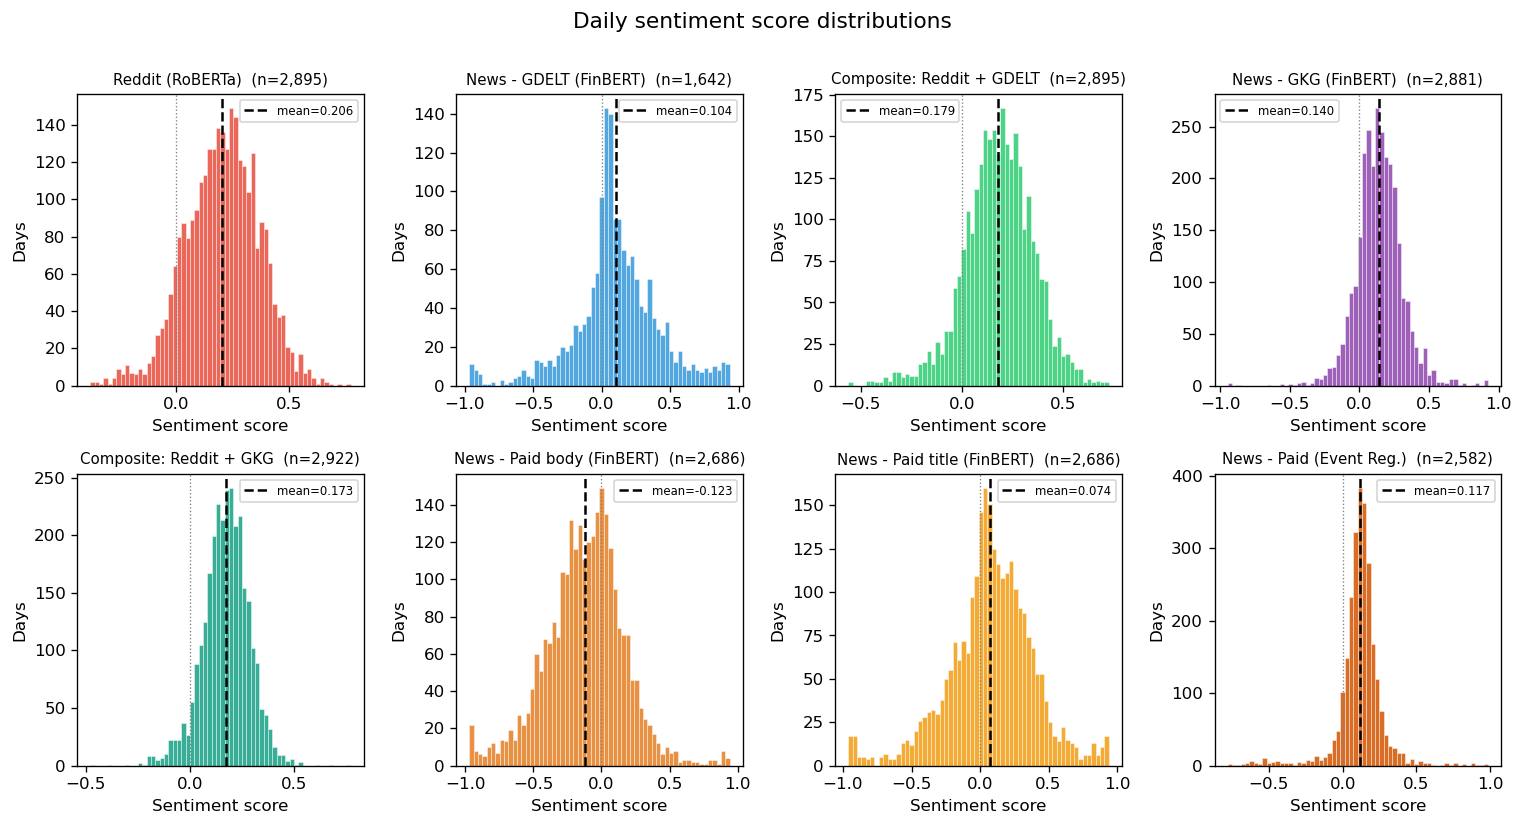

                            count   mean    std    min    25%    50%    75%  \
reddit_sentiment           2895.0  0.206  0.161 -0.378  0.101  0.213  0.318   
news_sentiment             1642.0  0.104  0.312 -0.966 -0.023  0.082  0.266   
sentiment_score            2895.0  0.179  0.172 -0.562  0.076  0.183  0.291   
gkg_sentiment              2881.0  0.140  0.167 -0.948  0.045  0.138  0.234   
sentiment_score_gkg        2922.0  0.173  0.113 -0.478  0.106  0.177  0.244   
news_paid_sentiment        2686.0 -0.123  0.288 -0.969 -0.292 -0.108  0.053   
news_paid_sentiment_title  2686.0  0.074  0.315 -0.960 -0.086  0.081  0.263   
news_paid_sentiment_er     2582.0  0.117  0.155 -0.780  0.067  0.123  0.179   

                             max  
reddit_sentiment           0.772  
news_sentiment             0.934  
sentiment_score            0.727  
gkg_sentiment              0.923  
sentiment_score_gkg        0.772  
news_paid_sentiment        0.940  
news_paid_sentiment_title  0.939  
news_pai

In [14]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Self-contained: read the saved CSV so this runs standalone (no dependency on §3-§6 being in memory).
daily_sentiment = pd.read_csv('../../data/processed/daily_sentiment.csv', index_col=0, parse_dates=True)

# Every sentiment-SCORE column = all columns except the volume ones (counts / weights / sums).
VOL = ('count', 'weight', 'sum')
score_cols = [c for c in daily_sentiment.columns if not any(k in c for k in VOL)]

# Nice labels/colours for the known columns; anything new falls back to its name + a default colour.
LABELS = {
    'reddit_sentiment':          ('Reddit (RoBERTa)',          '#e74c3c'),
    'news_sentiment':            ('News - GDELT (FinBERT)',     '#3498db'),
    'gkg_sentiment':             ('News - GKG (FinBERT)',       '#8e44ad'),
    'news_paid_sentiment_body':       ('News - Paid body (FinBERT)', '#e67e22'),
    'news_paid_sentiment_title': ('News - Paid title (FinBERT)','#f39c12'),
    'news_paid_sentiment_vader':    ('News - Paid (Event Reg.)',   '#d35400'),
    'sentiment_score':           ('Composite: Reddit + GDELT',  '#2ecc71'),
    'sentiment_score_gkg':       ('Composite: Reddit + GKG',    '#16a085'),
}

ncols = min(4, len(score_cols))
nrows = int(np.ceil(len(score_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, score_cols):
    label, color = LABELS.get(col, (col, '#7f8c8d'))
    data = daily_sentiment[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', lw=1.5, ls='--', label=f'mean={data.mean():.3f}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{label}  (n={len(data):,})', fontsize=9)
    ax.set_xlabel('Sentiment score'); ax.set_ylabel('Days'); ax.legend(fontsize=7)

for ax in axes[len(score_cols):]:        # hide any unused grid slots
    ax.axis('off')

plt.suptitle('Daily sentiment score distributions', fontsize=13, y=1.005)
plt.tight_layout(); plt.show()

print(daily_sentiment[score_cols].describe().round(3).T)
